
# Рабочая тетрадь 3

Выполнены задания по теме классификации и работы с признаками.


In [11]:
import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.datasets import load_iris
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

plt.rcParams['figure.figsize'] = (8, 5)



## 1.3.1 Задание

Задайте 4 точки в трёхмерном пространстве, рассчитайте между ними расстояния по описанным метрикам. Отобразите точки в трёхмерном пространстве.


  Пара точек  Евклидово  Квадрат евклидова  Манхэттенское  Чебышёва
0        A-B      4.123                 17              7         3
1        A-C      2.449                  6              4         2
2        A-D      5.196                 27              7         5
3        B-C      5.385                 29              9         4
4        B-D      3.742                 14              6         3
5        C-D      4.583                 21              7         4


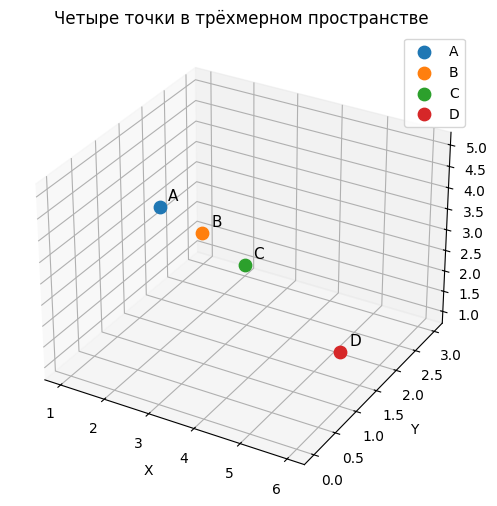

In [12]:
points = {
    'A': np.array([1, 2, 3]),
    'B': np.array([4, 0, 5]),
    'C': np.array([2, 3, 1]),
    'D': np.array([6, 1, 2]),
}

def euclidean(p1, p2):
    return np.linalg.norm(p1 - p2)

def squared_euclidean(p1, p2):
    diff = p1 - p2
    return np.dot(diff, diff)

def manhattan(p1, p2):
    return np.abs(p1 - p2).sum()

def chebyshev(p1, p2):
    return np.abs(p1 - p2).max()

rows = []
for left, right in itertools.combinations(points.keys(), 2):
    p1, p2 = points[left], points[right]
    rows.append({
        'Пара точек': f'{left}-{right}',
        'Евклидово': round(euclidean(p1, p2), 3),
        'Квадрат евклидова': round(squared_euclidean(p1, p2), 3),
        'Манхэттенское': round(manhattan(p1, p2), 3),
        'Чебышёва': round(chebyshev(p1, p2), 3),
    })

distance_df = pd.DataFrame(rows)
print(distance_df)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
for name, point in points.items():
    ax.scatter(*point, s=80, label=name)
    ax.text(point[0] + 0.1, point[1] + 0.1, point[2] + 0.1, name, fontsize=11)

ax.set_title('Четыре точки в трёхмерном пространстве')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()



## 1.3.2 Задание

Создать матрицу `5x5` со значениями в строках от `0` до `4` с использованием `arange`.


In [13]:
matrix_5x5 = np.arange(5).reshape(1, 5).repeat(5, axis=0)
print(matrix_5x5)


[[0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]
 [0 1 2 3 4]]



## 2.3.1 Задание

Для предыдущего примера поэкспериментировать с параметрами классификатора `k = 1, 5, 10`, размер тестовой выборки `15%`, построить графики и оценить качество моделей.


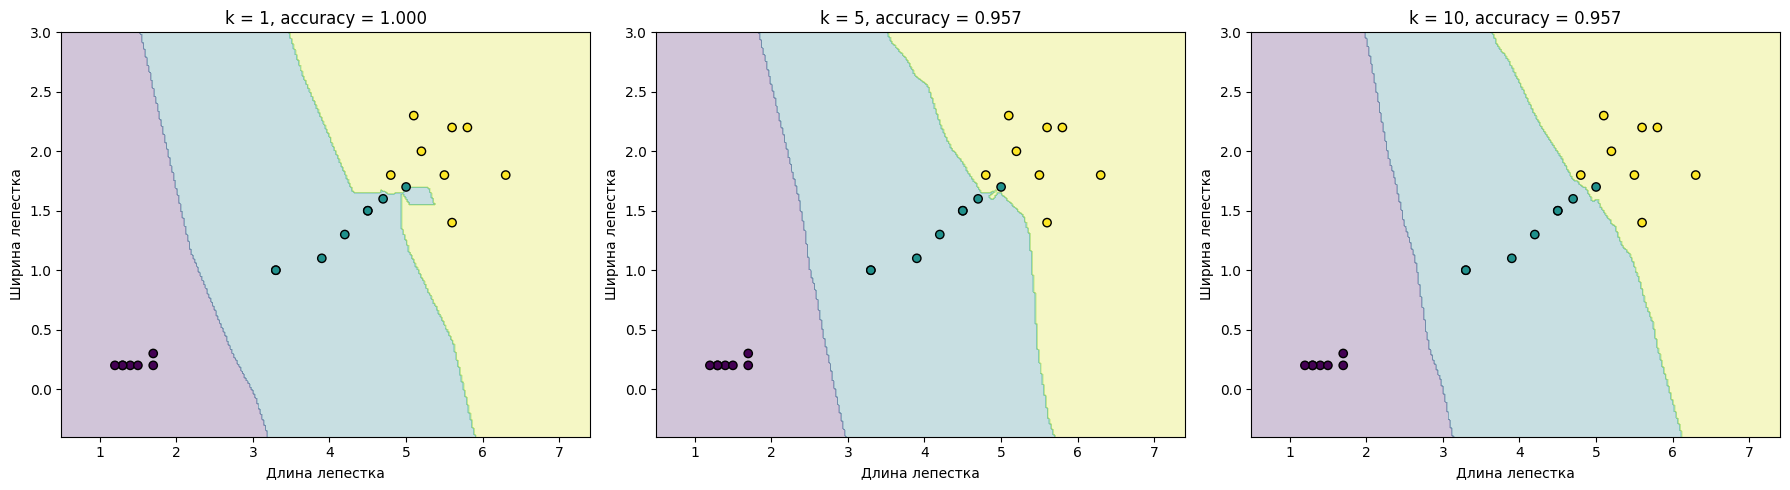

    k  accuracy
0   1    1.0000
1   5    0.9565
2  10    0.9565
Лучшая точность на этом разбиении: k = 1 -> 1.0000


In [10]:
iris = load_iris()
X = iris.data[:, 2:4]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = []
for ax, k in zip(axes, [1, 5, 10]):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    metrics.append({'k': k, 'accuracy': round(accuracy, 4)})

    grid_pred = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, grid_pred, alpha=0.25, cmap='viridis')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', edgecolor='k')
    ax.set_title(f'k = {k}, accuracy = {accuracy:.3f}')
    ax.set_xlabel('Длина лепестка')
    ax.set_ylabel('Ширина лепестка')

plt.tight_layout()
plt.show()

metrics_df = pd.DataFrame(metrics)
print(metrics_df)
best_row = metrics_df.sort_values('accuracy', ascending=False).iloc[0]
print(f"Лучшая точность на этом разбиении: k = {int(best_row['k'])} -> {best_row['accuracy']:.4f}")



## 3.3.2 Задание

Определить набор признаков человека и конвертировать его в матрицу признаков.


In [5]:
people = [
    {'имя': 'Анна', 'цвет_глаз': 'карие', 'цвет_волос': 'русые', 'город': 'Москва'},
    {'имя': 'Борис', 'цвет_глаз': 'голубые', 'цвет_волос': 'тёмные', 'город': 'Казань'},
    {'имя': 'Вера', 'цвет_глаз': 'зелёные', 'цвет_волос': 'рыжие', 'город': 'Сочи'},
]

vectorizer = DictVectorizer(sparse=False)
feature_matrix = vectorizer.fit_transform([
    {key: value for key, value in person.items() if key != 'имя'}
    for person in people
])

feature_df = pd.DataFrame(
    feature_matrix,
    columns=vectorizer.get_feature_names_out(),
    index=[person['имя'] for person in people],
)
print(feature_df)


       город=Казань  город=Москва  город=Сочи  цвет_волос=русые  \
Анна            0.0           1.0         0.0               1.0   
Борис           1.0           0.0         0.0               0.0   
Вера            0.0           0.0         1.0               0.0   

       цвет_волос=рыжие  цвет_волос=тёмные  цвет_глаз=голубые  \
Анна                0.0                0.0                0.0   
Борис               0.0                1.0                1.0   
Вера                1.0                0.0                0.0   

       цвет_глаз=зелёные  цвет_глаз=карие  
Анна                 0.0              1.0  
Борис                0.0              0.0  
Вера                 1.0              0.0  
